## E-Commerce Purchase Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

In [11]:
# Data
data = {
    "Age": [22, 35, 28, 42, 31, 25, 45, 36, 29, 52,
            24, 39, 33, 48, 27, 41, 30, 55, 23, 37],

    "Time_On_Site": [5, 18, 12, 25, 20, 7, 30, 22, 10, 35,
                     8, 28, 16, 32, 6, 24, 14, 40, 9, 21],

    "Pages_Viewed": [2, 8, 5, 12, 9, 3, 15, 10, 4, 18,
                     3, 13, 7, 16, 2, 11, 6, 20, 4, 9],

    "Previous_Purchases": [0, 3, 1, 5, 2, 0, 6, 4, 1, 8,
                           0, 5, 2, 7, 0, 4, 2, 9, 1, 3],

    "Added_To_Cart": ["No", "Yes", "Yes", "Yes", "Yes",
                      "No", "Yes", "Yes", "No", "Yes",
                      "No", "Yes", "Yes", "Yes", "No",
                      "Yes", "Yes", "Yes", "No", "Yes"],

    "Purchased": ["No", "Yes", "No", "Yes", "Yes",
                  "No", "Yes", "Yes", "No", "Yes",
                  "No", "Yes", "Yes", "Yes", "No",
                  "Yes", "No", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)
df

,Age,Time_On_Site,Pages_Viewed,Previous_Purchases,Added_To_Cart,Purchased
0,22,5,2,0,No,No
1,35,18,8,3,Yes,Yes
2,28,12,5,1,Yes,No
3,42,25,12,5,Yes,Yes
4,31,20,9,2,Yes,Yes
5,25,7,3,0,No,No
6,45,30,15,6,Yes,Yes
7,36,22,10,4,Yes,Yes
8,29,10,4,1,No,No
9,52,35,18,8,Yes,Yes


#### **Observation**: *In the above dataframe we can observe that there are no categorical variables except 'Added_To_Cart'.*

In [12]:
# Using one-hot encoding encode 'Added_To_Cart'
df["Added_To_Cart"] = df["Added_To_Cart"].map({
    "No": 0,
    "Yes": 1
})

In [13]:
df.head()

,Age,Time_On_Site,Pages_Viewed,Previous_Purchases,Added_To_Cart,Purchased
0,22,5,2,0,0,No
1,35,18,8,3,1,Yes
2,28,12,5,1,1,No
3,42,25,12,5,1,Yes
4,31,20,9,2,1,Yes


In [15]:
# Seperate dependent and independent variables
X = df.drop('Purchased',axis=1).copy()
y = df['Purchased'].copy()

### Build a preliminary decision tree

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [18]:
clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt = clf_dt.fit(X_train,y_train)

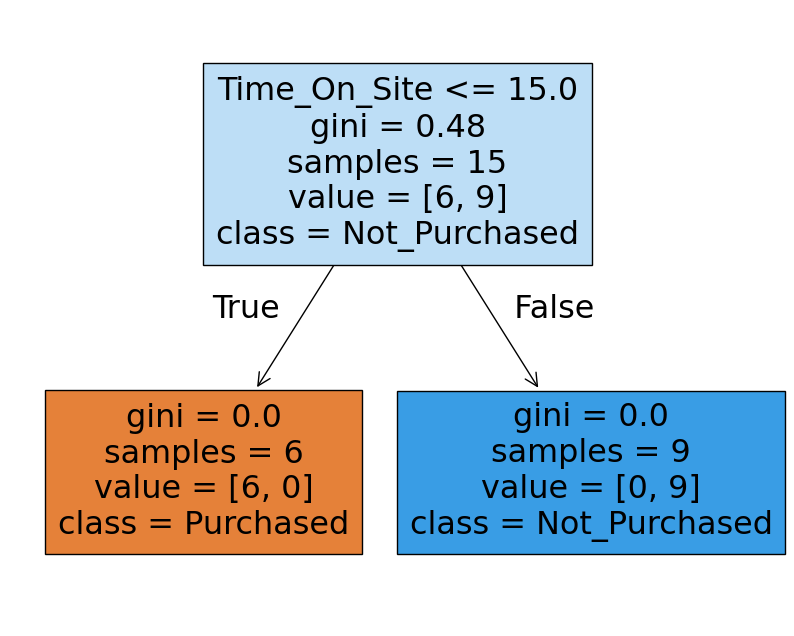

In [31]:
# Plot the tree and check if there is need for post-pruning
plt.figure(figsize=(10,8))
plot_tree(clf_dt, filled=True, class_names=['Purchased','Not_Purchased'], feature_names=X.columns);

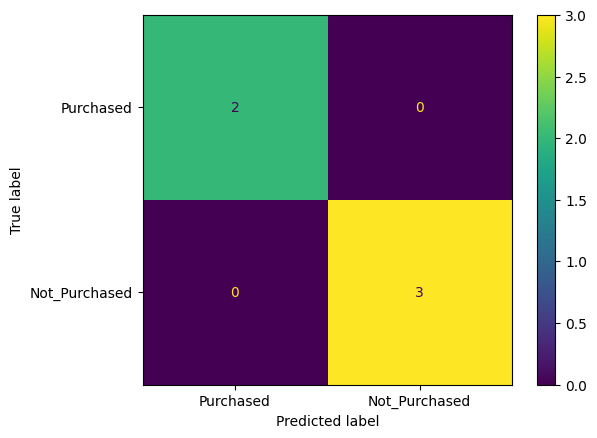

In [28]:
# Use confusion matrix to analyze test data
ConfusionMatrixDisplay.from_estimator(clf_dt,X_test,y_test,display_labels=['Purchased','Not_Purchased'])

In [32]:
# Let's make predictions on test data
y_pred = clf_dt.predict(X_test)
y_pred

array(['No', 'Yes', 'Yes', 'Yes', 'No'], dtype=object)

In [33]:
# Check accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
print(acc)

1.0


In [47]:
# New Customer
new_customer = pd.DataFrame([[29, 22, 9, 2, 1]])
pred = clf_dt.predict(new_customer)

if pred[0]=='Yes':
    print('Customer will buy')
else:
    print('Customer will not buy')


Customer will buy


c:\Python-3\Pyth\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#### **Observation**: *As we are getting accuracy=1 on test data, we can say that this decision tree can work well with new_customer data.*